In [1]:
# loading libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import os
sns.set()

### Loading Data

In [2]:
# load the data 
df = pd.read_csv('./Data/cleaned_high_pay_data.csv')
# check the first 5 rows of the data
df.columns

Index(['State Abbreviation', 'State', 'Gender', 'Age', 'Education Code',
       'Education Level', 'Degree Field', 'Occupation Code', 'Occupation',
       'Annual Income', 'Employment', 'Location Quotient', 'Jobs per 1000',
       'Hourly Mean', 'Annual Mean Wage'],
      dtype='object')

Question 1: Which occupations have the highest average annual income?

1. Data Preparetion

In [4]:
# Group by Occupation and calculate the average income
top_occupations = df.groupby('Occupation')['Annual Income'].mean().sort_values(ascending=False).head(10)

2. Visualization

C:\Users\marwa\AppData\Local\Temp\ipykernel_12496\595575487.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


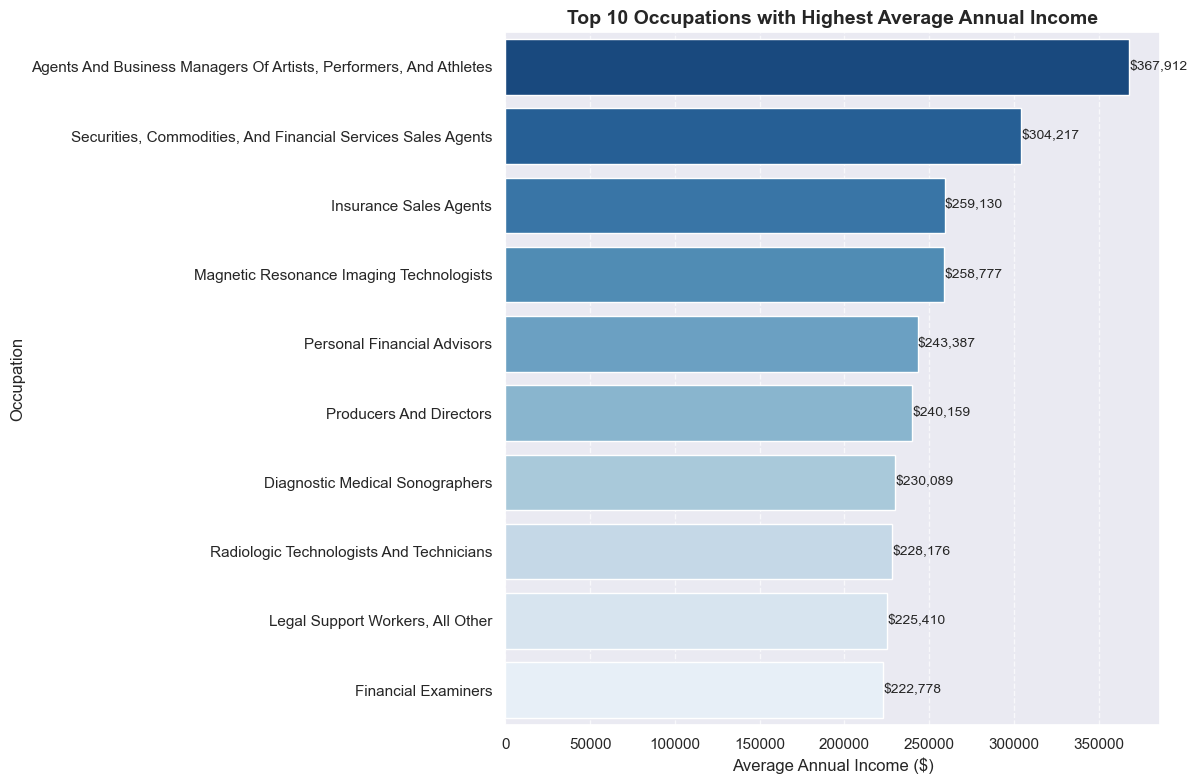

Plot saved to: Images/Top_Occupations_Avg_Income.png


In [17]:
# Ensure the folder exists
os.makedirs('Images', exist_ok=True)


# Create the horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_occupations.values,
    y=top_occupations.index,
    palette="Blues_r"
)

# Annotate each bar with the average income value
for i, value in enumerate(top_occupations.values):
    plt.text(value, i, f"${value:,.0f}", va='center', ha='left', fontsize=10)

# Finalize the plot
plt.title("Top 10 Occupations with Highest Average Annual Income", fontsize=14, weight='bold')
plt.xlabel("Average Annual Income ($)", fontsize=12)
plt.ylabel("Occupation", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plot_path = 'Images/Top_Occupations_Avg_Income.png'
plt.savefig(plot_path)
plt.show()

print(f"Plot saved to: {plot_path}")


Question 2: What is the average annual income by education level?

Data Preparation

In [20]:
# Group by Education Level and calculate the average annual income
education_income = df.groupby('Education Level')['Annual Income'].mean().sort_values().reset_index()

Visualizaton

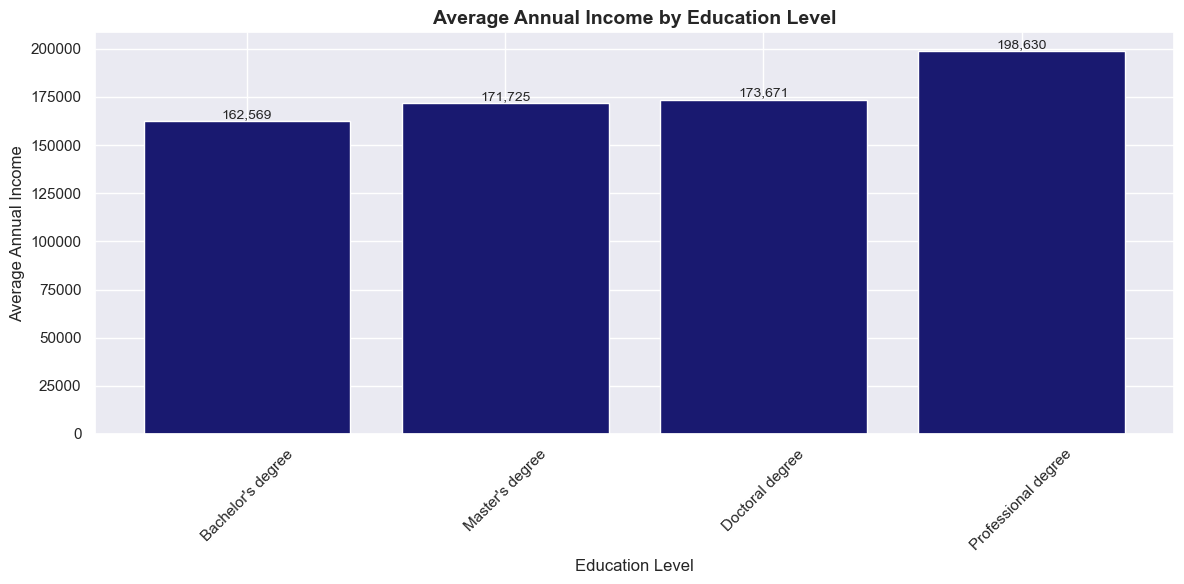

Plot saved to: Images/Average_Income_by_Education_Level.png


In [23]:
# Plotting
plt.figure(figsize=(12, 6))
bars = plt.bar(
    x=education_income['Education Level'],  # Use the category labels from the DataFrame
    height=education_income['Annual Income'], 
    color='midnightblue'  # Professional color choice
)

# Add annotations to each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center the text on each bar
        bar.get_height(),  # Place the text just above the bar
        f'{bar.get_height():,.0f}',  # Format the number with commas for better readability
        ha='center',  # Horizontally center the annotation
        va='bottom',  # Position just above the bar
        fontsize=10
    )

# Final plot adjustments
plt.xticks(rotation=45)
plt.title('Average Annual Income by Education Level', fontsize=14, weight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Annual Income', fontsize=12)
plt.tight_layout()

# Save the plot
plot_path = 'Images/Average_Income_by_Education_Level.png'
plt.savefig(plot_path, bbox_inches='tight')  # Save before showing
plt.show()

print(f"Plot saved to: {plot_path}")


Question 3: How does gender distribution vary across high-paying occupations?


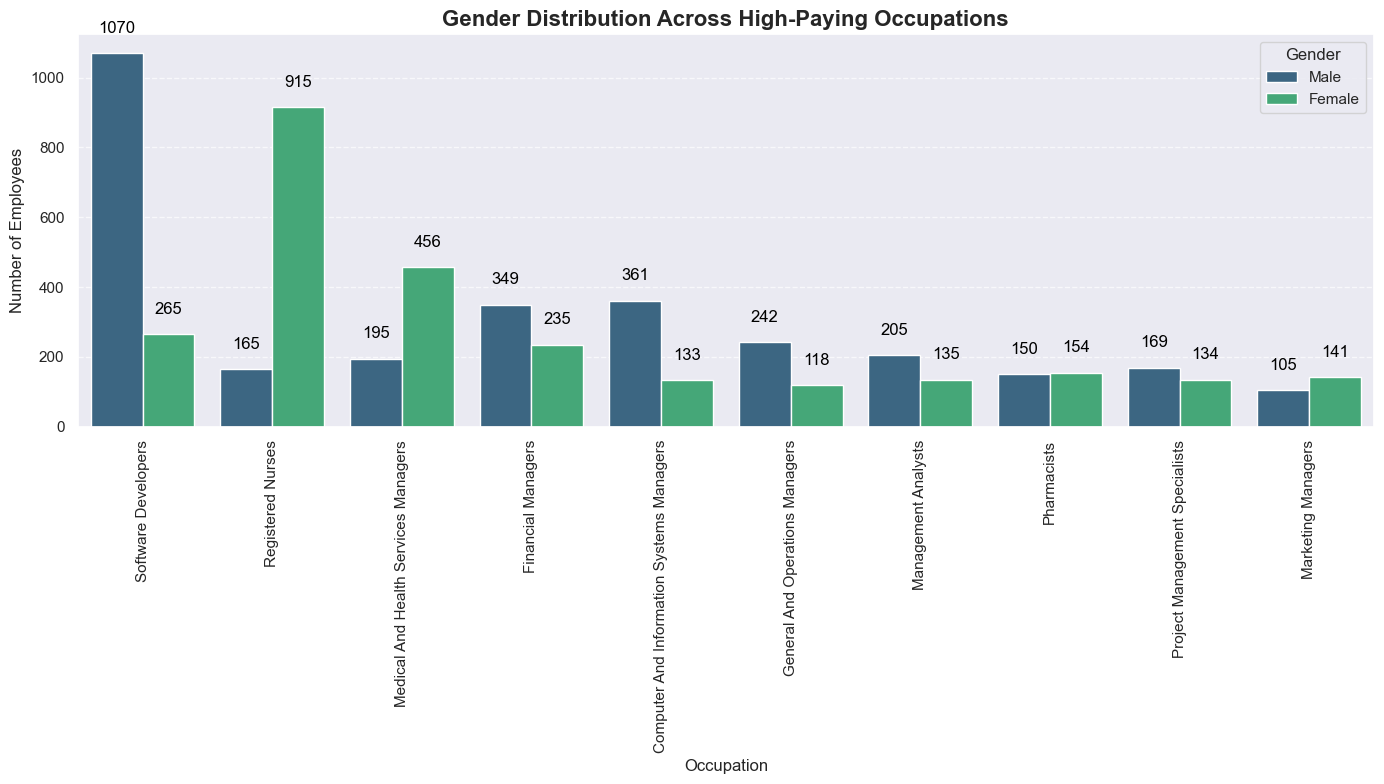

Plot saved to: Images/Gender_Distribution_Occupations_Refined.png


In [ ]:
# Set the figure size
plt.figure(figsize=(14, 8))

# Create countplot for gender distribution across the most common high-paying occupations
sns.countplot(
    x='Occupation', 
    hue='Gender', 
    data=df, 
    order=df['Occupation'].value_counts().index[:10],  # Top 10 occupations by number of employees
    palette='viridis'
)

# Annotate number of employees at the top of each bar with improved offset
for p in plt.gca().containers:  # Loop over the bar containers
    for bar in p:
        # Calculate annotation position just above the bar
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center annotation horizontally on bar
            height + 50,  # Slight offset above each bar
            f'{int(height)}',  # Display the number of employees
            ha='center',
            va='bottom',  # Align text to the bottom of the offset
            fontsize=12,
            color='black'
        )

# Add additional aesthetic customizations
plt.title('Gender Distribution Across High-Paying Occupations', fontsize=16, weight='bold')
plt.xlabel('Occupation', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels for better readability
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal gridlines
plt.tight_layout()

# Save the plot
plot_path = 'Images/Gender_Distribution_Occupations_Refined.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_path}")

Question 4: How is the gender distribution in high-paying jobs ($100K+) across different states?



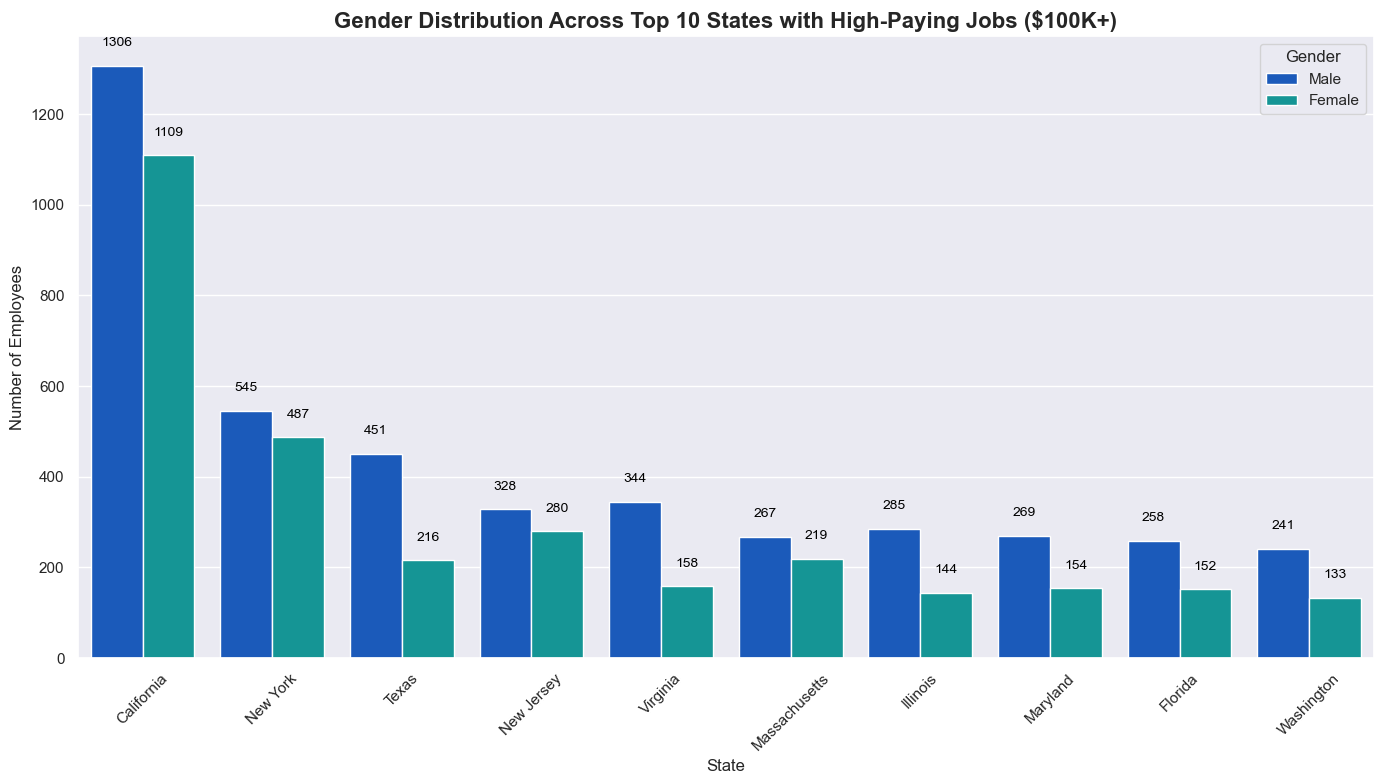

Plot saved to: Images/Gender_Distribution_States.png


In [31]:
# Set the figure size
plt.figure(figsize=(14, 8))

# Create a countplot to show gender distribution across the top states with high-paying jobs
sns.countplot(
    x='State',
    hue='Gender',
    data=df,  
    order=df['State'].value_counts().index[:10],  # Select top 10 states by number of high-paying jobs
    palette='winter'
)

# Annotate the counts on the bars
for p in plt.gca().containers:
    for bar in p:
        # Calculate annotation position just above each bar
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center annotation
            height + 50,  # Slight offset above the bar
            f'{int(height)}',
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

# Add additional styling and labels
plt.title('Gender Distribution Across Top 10 States with High-Paying Jobs ($100K+)', fontsize=16, weight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis for better clarity
plt.legend(title='Gender')
plt.tight_layout()

# Save the plot
plot_path = 'Images/Gender_Distribution_States.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_path}")


"What are the most common education levels and their relationship with gender distribution in high-paying jobs ($100K+) across states?"

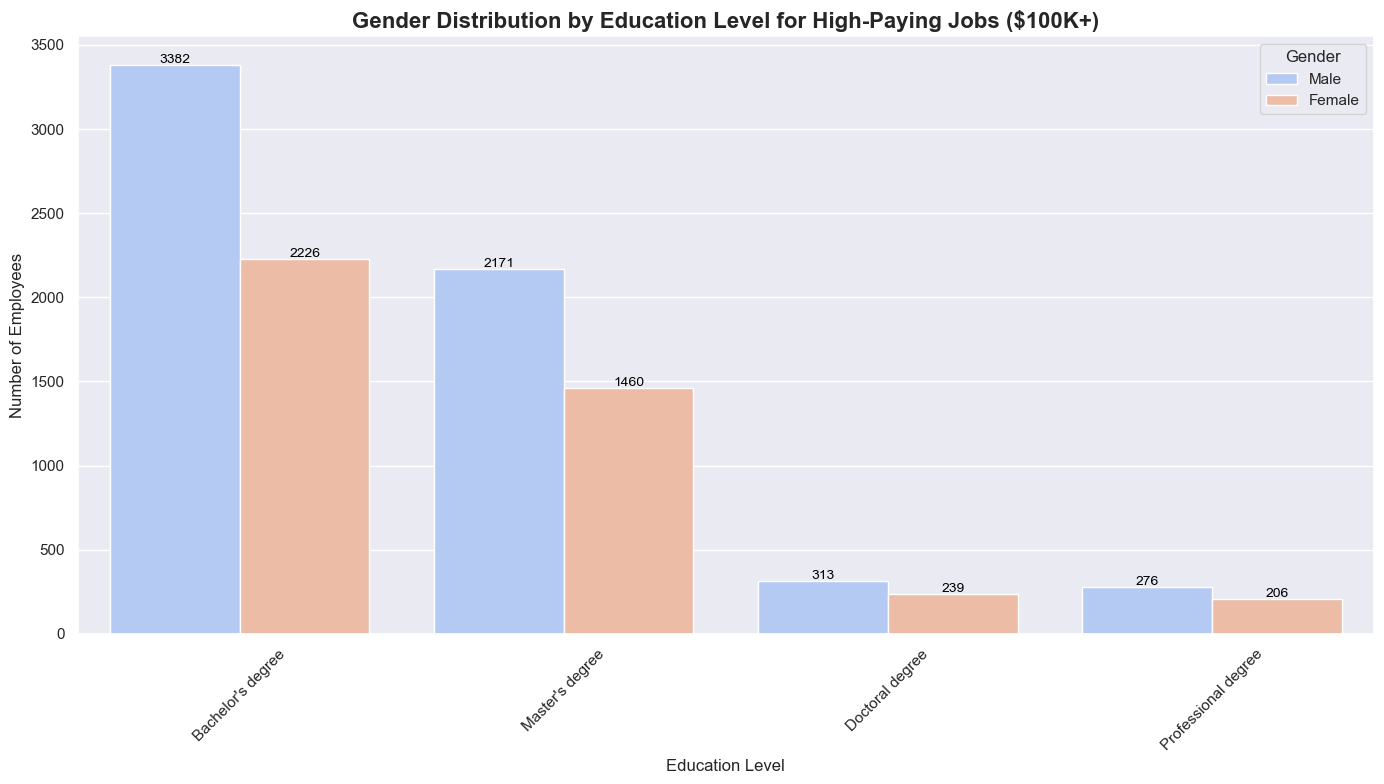

Plot saved to: Images/Gender_Education_Distribution.png


In [30]:
# Set the figure size
plt.figure(figsize=(14, 8))

# Filter data for high-paying jobs only
high_paying_df = df[df['Annual Income'] >= 100000]

# Create a countplot to show the gender distribution by education level
sns.countplot(
    x='Education Level',
    hue='Gender',
    data=high_paying_df,
    order=high_paying_df['Education Level'].value_counts().index[:10],  # Filter the top 10 most common education levels
    palette='coolwarm'
)

# Annotate counts on top of each bar
for p in plt.gca().containers:
    for bar in p:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center annotation
            height + 30,  # Slight offset above the bar
            f'{int(height)}',
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

# Additional styling for better visualization
plt.title('Gender Distribution by Education Level for High-Paying Jobs ($100K+)', fontsize=16, weight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis for better clarity
plt.legend(title='Gender')
plt.tight_layout()

# Save the plot
plot_path = 'Images/Gender_Education_Distribution.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_path}")


What is the relationship between age and annual income for high-paying jobs?

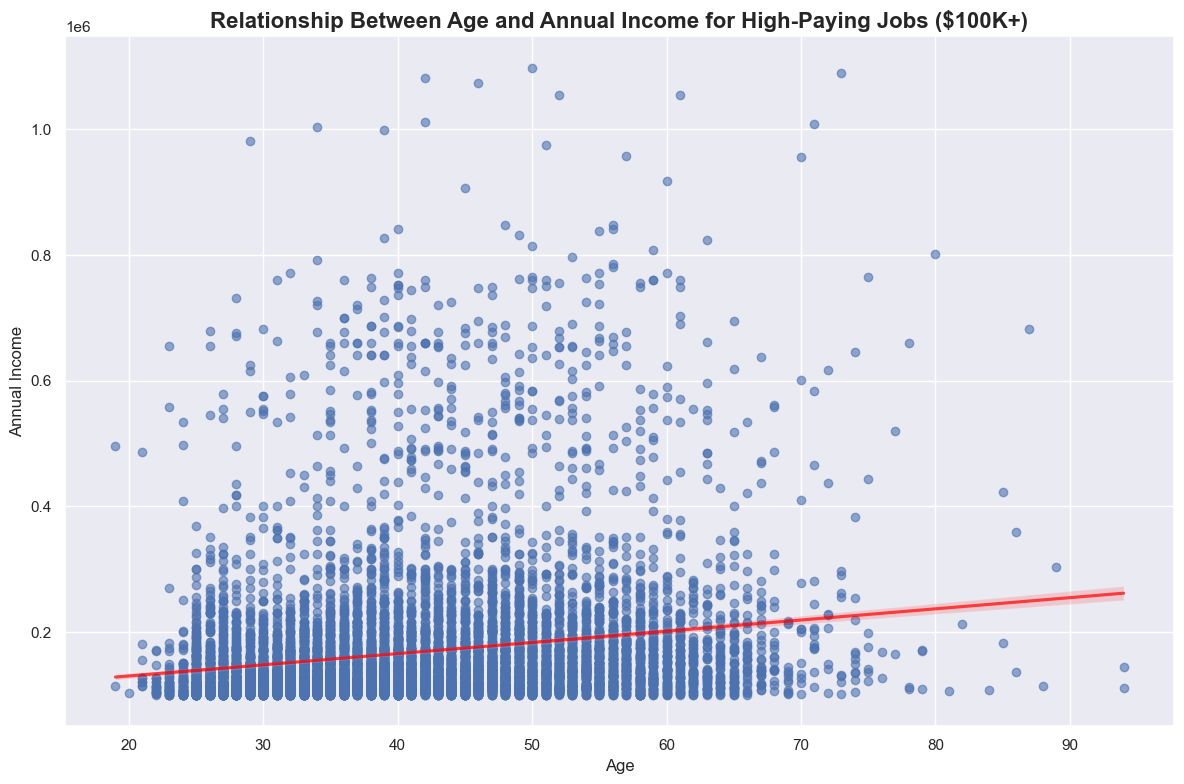

Plot saved to: Images/Age_Annual_Income.png


In [33]:
# Plotting the relationship between age and annual income
plt.figure(figsize=(12, 8))
sns.regplot(
    x='Age', 
    y='Annual Income', 
    data=df, 
    scatter_kws={'alpha': 0.6},  # Make points slightly transparent for better visibility
    line_kws={'color': 'red', 'alpha': 0.7}  # Regression line
)

# Finalize plot
plt.title('Relationship Between Age and Annual Income for High-Paying Jobs ($100K+)', fontsize=16, weight='bold')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = 'Images/Age_Annual_Income.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_path}")


Question 7: What is the gender distribution in high-paying jobs ($100K+) across different states?


<Figure size 1400x800 with 0 Axes>

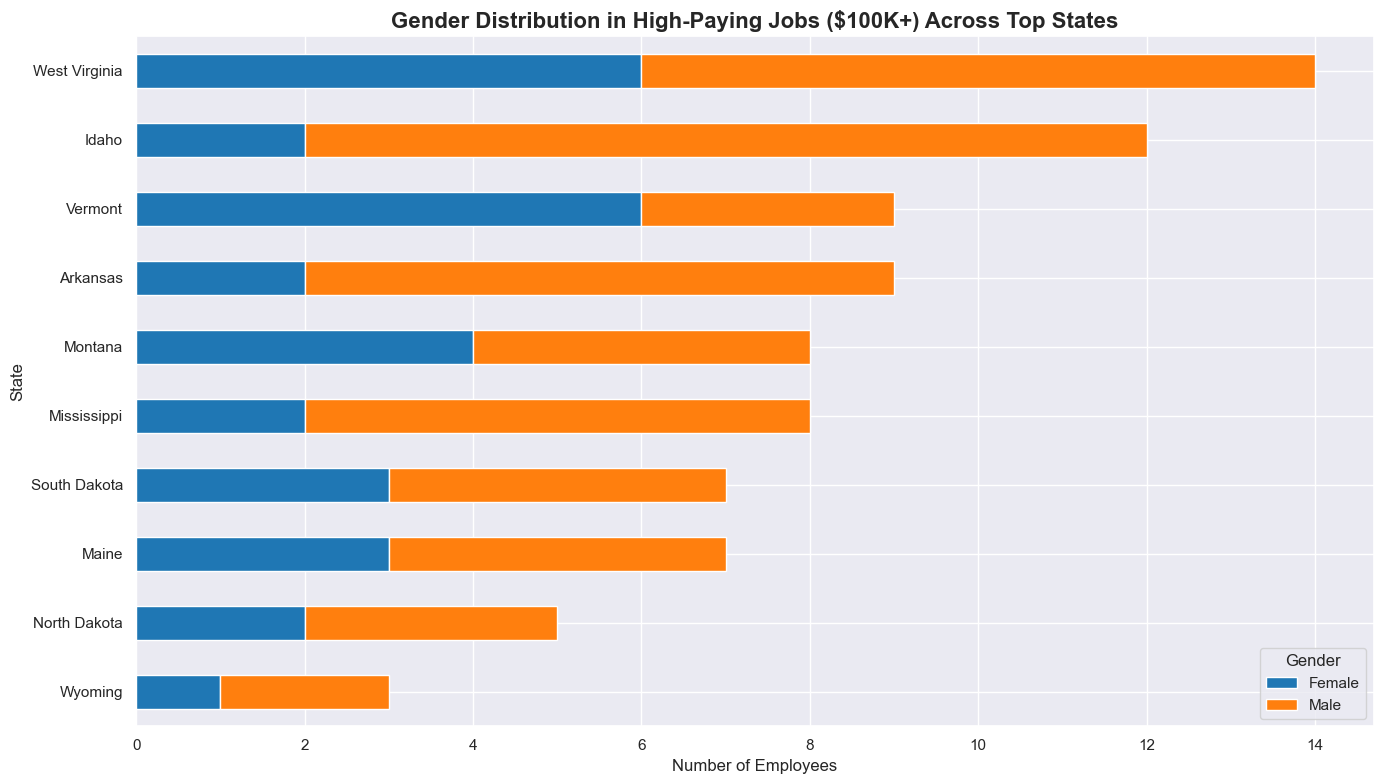

Plot saved to: Images/Gender_Distribution.png


In [34]:
# Group by state and gender to compute counts
gender_distribution = df.groupby(['State', 'Gender']).size().reset_index(name='Count')

# Pivot the data to have genders as columns for stacked bar plotting
gender_pivot = gender_distribution.pivot(index='State', columns='Gender', values='Count').fillna(0)

# Sort by total number of high-paying jobs
top_states = gender_pivot.sum(axis=1).sort_values(ascending=True).head(10)  # Select top 10 states
gender_pivot = gender_pivot.loc[top_states.index]

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))
gender_pivot.plot(kind='barh', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(14, 8))

# Finalize the plot
plt.title('Gender Distribution in High-Paying Jobs ($100K+) Across Top States', fontsize=16, weight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('State')
plt.legend(title="Gender")
plt.tight_layout()

# Save the plot
plot_path = 'Images/Gender_Distribution.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_path}")


 Question 5: What are the most common occupations among high-paid individuals?

In [4]:
# Group data to find the most common occupations among high-paid individuals
top_occupations = df['Occupation'].value_counts().head(10)

C:\Users\marwa\AppData\Local\Temp\ipykernel_14004\2387571282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


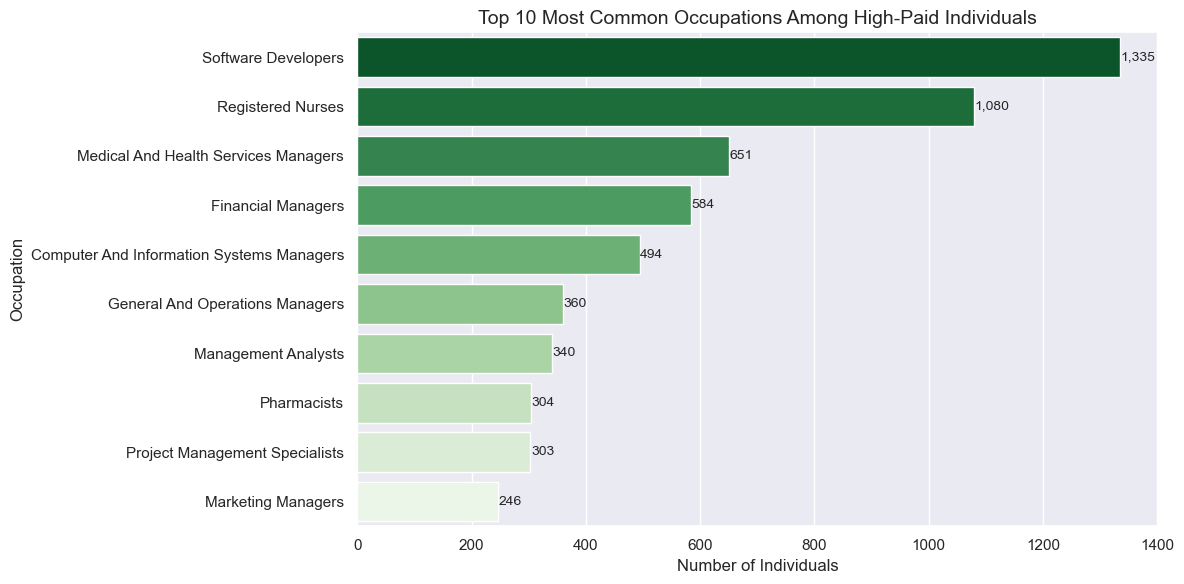

Plot saved to: Images/Top_Occupations_High_Paid.png


In [5]:


# Set up the figure
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_occupations.values,
    y=top_occupations.index,
    palette="Greens_r"
)

# Annotate counts at the end of each bar
for index, value in enumerate(top_occupations.values):
    plt.text(value + 1, index, f"{value:,}", va='center', fontsize=10)  # Add commas for readability

# Add titles and labels
plt.title('Top 10 Most Common Occupations Among High-Paid Individuals', fontsize=14)
plt.xlabel('Number of Individuals', fontsize=12)
plt.ylabel('Occupation', fontsize=12)
plt.tight_layout()

# Save the plot
plot_path = 'Images/Top_Occupations_High_Paid.png'
plt.savefig(plot_path)
plt.show()

print(f"Plot saved to: {plot_path}")


Question 6: What is the distribution of high-paid individuals across different states?

In [7]:
import plotly.express as px

# Aggregate the number of high-paid individuals by state
state_distribution = df.groupby('State Abbreviation')['Annual Income'].count().reset_index()
state_distribution.columns = ['State', 'High Paid Individuals']


 Question 7: How does the average salary vary across different occupations?


C:\Users\marwa\AppData\Local\Temp\ipykernel_14004\2930047456.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\marwa\AppData\Local\Temp\ipykernel_14004\2930047456.py:13: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



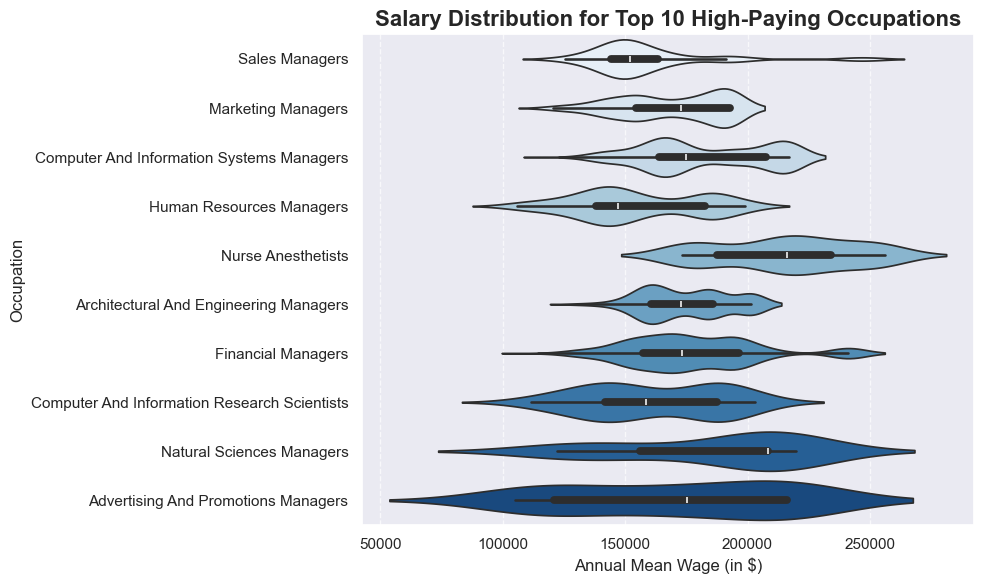

Plot saved to: Images/Top_10_Salary_Distribution.png


In [11]:
# Filter for top 10 occupations with the highest average salaries
top_occupations = (
    df.groupby('Occupation')['Annual Mean Wage']
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)
)

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the violin plot
sns.violinplot(
    data=df[df['Occupation'].isin(top_occupations.index)],
    x='Annual Mean Wage',
    y='Occupation',
    palette='Blues',
    scale='width'
)

# Add plot annotations and titles
plt.title('Salary Distribution for Top 10 High-Paying Occupations', fontsize=16, fontweight='bold')
plt.xlabel('Annual Mean Wage (in $)', fontsize=12)
plt.ylabel('Occupation', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save the plot
plot_path = 'Images/Top_10_Salary_Distribution.png'
plt.tight_layout()
plt.savefig(plot_path)
plt.show()

print(f"Plot saved to: {plot_path}")


 7: How does the average salary vary across different occupations?


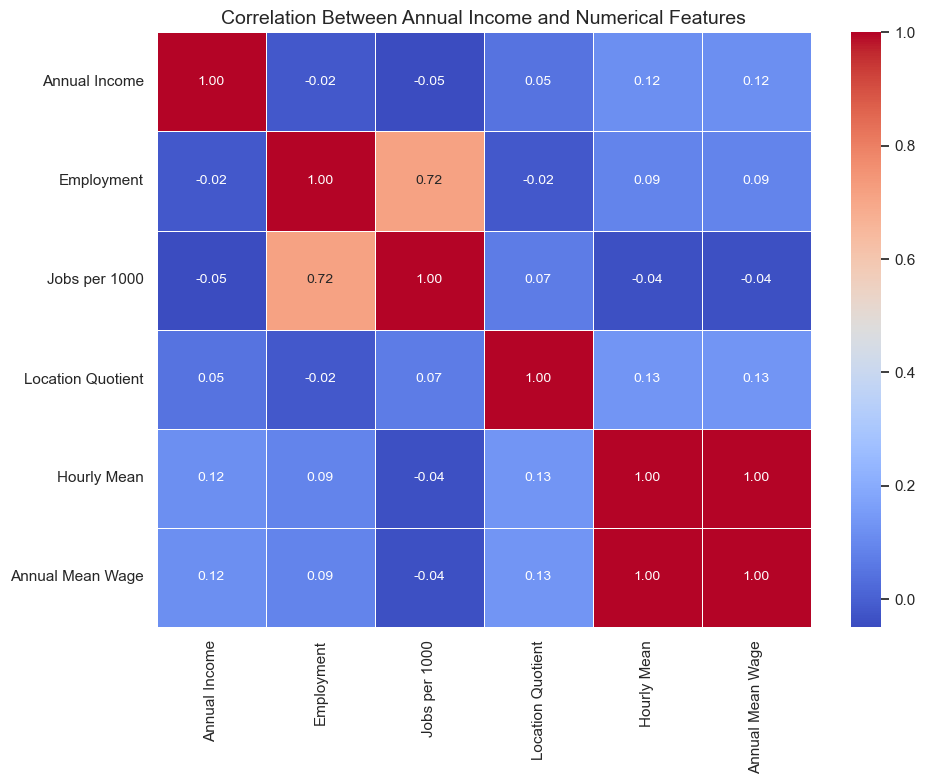

Plot saved to: Images/Correlation_Annual_Income.png


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting numerical columns for correlation
numerical_columns = [
    'Annual Income', 'Employment', 'Jobs per 1000', 
    'Location Quotient', 'Hourly Mean', 'Annual Mean Wage'
]

# Calculating the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    annot_kws={"size": 10}
)

plt.title('Correlation Between Annual Income and Numerical Features', fontsize=14)
plt.tight_layout()

# Save the heatmap
plot_path = 'Images/Correlation_Annual_Income.png'
plt.savefig(plot_path)
plt.show()

print(f"Plot saved to: {plot_path}")


The correlation analysis shows the following straightforward insights:

Annual Income has weak or negligible correlations with other features, suggesting factors beyond this dataset might drive income differences.
Employment and Jobs per 1000 are strongly correlated, indicating that areas with more employment opportunities naturally have more jobs available per capita.
Location Quotient slightly correlates with Hourly Mean and Annual Mean Wage, implying that regions with higher job concentrations might offer better wages.
Hourly Mean and Annual Mean Wage are perfectly correlated, as expected, since annual wages are calculated from hourly rates.
This suggests income is weakly influenced by job concentration or employment but may depend on other variables.